In [1]:
import numpy as np

In [ ]:
def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

def binary_cross_entropy(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def red_neuronal(inputs, n_capas, y_obj, lr=0.01, max_iters=5000, seed=42):
    np.random.seed(seed)

    capas = {}
    losses = []
    for i in range(len(n_capas) - 1):
        fan_in = n_capas[i]
        fan_out = n_capas[i + 1]

        capas[f"pesos{i}"] = np.random.randn(fan_in, fan_out) * np.sqrt(2.0 / fan_in)
        capas[f"bias{i}"] = np.zeros((1, fan_out))

    for iter in range(max_iters):
        activaciones = [inputs]
        zs = []

        a = inputs
        for j in range(len(n_capas) - 1):
            z = a @ capas[f"pesos{j}"] + capas[f"bias{j}"]
            zs.append(z)

            if j == len(n_capas) - 2:
                a = sigmoid(z)
            else:
                a = np.maximum(0, z)  # ReLU

            activaciones.append(a)

        y_pred = activaciones[-1]
        loss = binary_cross_entropy(y_obj, y_pred)
        losses.append(loss)

        if iter % 100 == 0:
            print(f"Iter {iter:4d} | Loss: {loss:.6f}")

        if loss < 0.01:
            print("Convergió!")
            break

        gradientes = {}

        # Con sigmoid + BCE, este gradiente se simplifica mucho:
        dA = (y_pred - y_obj) / y_obj.shape[0]

        for j in reversed(range(len(n_capas) - 1)):
            a_prev = activaciones[j]
            z_actual = zs[j]

            # Gradientes de parámetros
            dW = a_prev.T @ dA
            dB = np.sum(dA, axis=0, keepdims=True)

            gradientes[f"dW{j}"] = dW
            gradientes[f"dB{j}"] = dB

            if j > 0:
                dA = dA @ capas[f"pesos{j}"].T
                dA = dA * (zs[j - 1] > 0)  # derivada de ReLU usando Z previa

        for j in range(len(n_capas) - 1):
            capas[f"pesos{j}"] -= lr * gradientes[f"dW{j}"]
            capas[f"bias{j}"] -= lr * gradientes[f"dB{j}"]

    return capas, losses

🌀 Generando espirales...

🧠 Entrenando TU red neuronal desde cero...
Iter    0 | Loss: 0.473651
Iter  100 | Loss: 0.242054
Iter  200 | Loss: 0.238034
Iter  300 | Loss: 0.235380
Iter  400 | Loss: 0.232927
Iter  500 | Loss: 0.230757
Iter  600 | Loss: 0.228835
Iter  700 | Loss: 0.226834
Iter  800 | Loss: 0.224702
Iter  900 | Loss: 0.222384
Iter 1000 | Loss: 0.219860
Iter 1100 | Loss: 0.217227
Iter 1200 | Loss: 0.214592
Iter 1300 | Loss: 0.212079
Iter 1400 | Loss: 0.209740
Iter 1500 | Loss: 0.207576
Iter 1600 | Loss: 0.205583
Iter 1700 | Loss: 0.203638
Iter 1800 | Loss: 0.201912
Iter 1900 | Loss: 0.200192
Iter 2000 | Loss: 0.198477
Iter 2100 | Loss: 0.196729
Iter 2200 | Loss: 0.195006
Iter 2300 | Loss: 0.193055
Iter 2400 | Loss: 0.190947
Iter 2500 | Loss: 0.188868
Iter 2600 | Loss: 0.186600
Iter 2700 | Loss: 0.184151
Iter 2800 | Loss: 0.181529
Iter 2900 | Loss: 0.178540
Iter 3000 | Loss: 0.175173
Iter 3100 | Loss: 0.171399
Iter 3200 | Loss: 0.167110
Iter 3300 | Loss: 0.161812
Iter 3400 | L

C:\Users\usuario\AppData\Local\Temp\ipykernel_17292\3908229424.py:15: RuntimeWarning: overflow encountered in matmul
  z = activaciones[-1] @ capas[f"pesos{j}"] + capas[f"bias{j}"]
C:\Users\usuario\AppData\Local\Temp\ipykernel_17292\3908229424.py:15: RuntimeWarning: invalid value encountered in matmul
  z = activaciones[-1] @ capas[f"pesos{j}"] + capas[f"bias{j}"]


Iter 4500 | Loss: nan
Iter 4600 | Loss: nan
Iter 4700 | Loss: nan
Iter 4800 | Loss: nan
Iter 4900 | Loss: nan

📊 Visualizando resultado...


C:\Users\usuario\AppData\Local\Temp\ipykernel_17292\3111939828.py:71: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


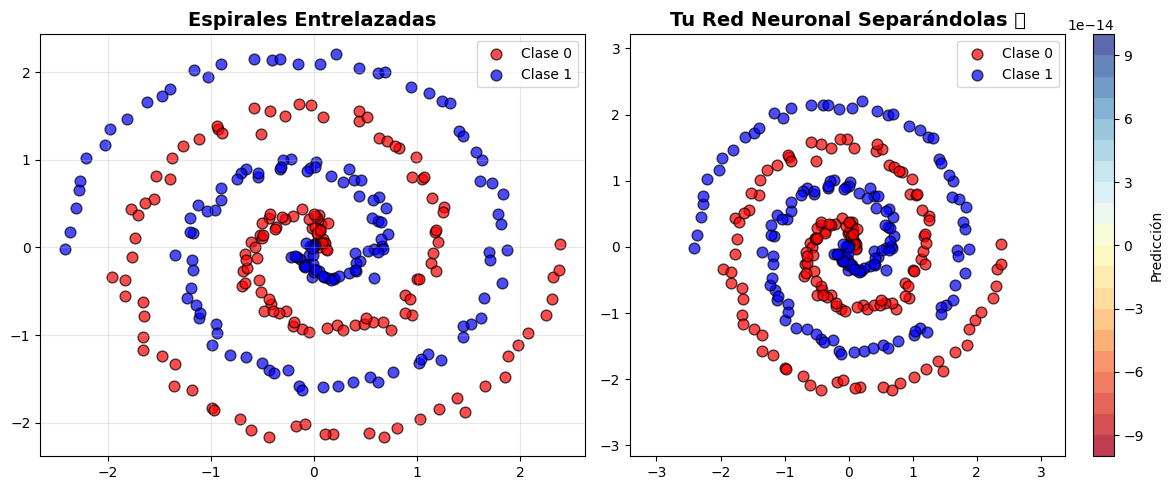

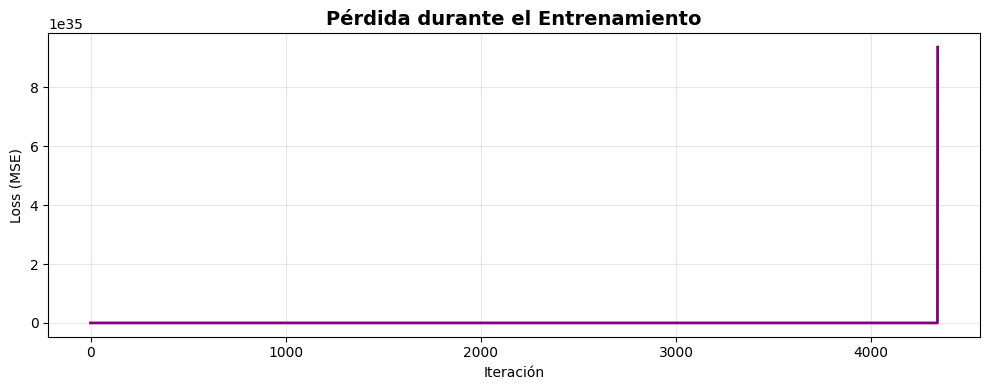


✅ Accuracy final: 50.00%


In [21]:
import numpy as np
import matplotlib.pyplot as plt

# ===== GENERAR ESPIRALES =====
def crear_espirales(n_puntos=100, ruido=0.2):
    n = n_puntos
    theta = np.linspace(0, 4*np.pi, n)
    
    # Espiral 1
    r1 = theta
    x1 = r1 * np.cos(theta) + np.random.randn(n) * ruido
    y1 = r1 * np.sin(theta) + np.random.randn(n) * ruido
    
    # Espiral 2 (rotada 180°)
    r2 = theta
    x2 = r2 * np.cos(theta + np.pi) + np.random.randn(n) * ruido
    y2 = r2 * np.sin(theta + np.pi) + np.random.randn(n) * ruido
    
    X = np.vstack([np.column_stack([x1, y1]), 
                   np.column_stack([x2, y2])])
    y = np.vstack([np.zeros((n, 1)), np.ones((n, 1))])
    
    # ✅ AÑADE ESTA LÍNEA - LA CLAVE
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    
    indices = np.random.permutation(2*n)
    return X[indices], y[indices]

# ===== VISUALIZACIÓN =====
def visualizar_resultado(modelo, X, y, n_capas):
    # Crear grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Predecir en cada punto
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    z = grid_points
    for j in range(len(n_capas) - 1):
        z = z @ modelo[f"pesos{j}"] + modelo[f"bias{j}"]
        if j != len(n_capas) - 2:
            z = np.maximum(0, z)
    
    zz = z.reshape(xx.shape)
    
    # Plot
    plt.figure(figsize=(12, 5))
    
    # Subplot 1: Dataset
    plt.subplot(1, 2, 1)
    plt.scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1], 
                c='red', s=60, edgecolors='k', label='Clase 0', alpha=0.7)
    plt.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1], 
                c='blue', s=60, edgecolors='k', label='Clase 1', alpha=0.7)
    plt.title('Espirales Entrelazadas', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Subplot 2: Fronteras de decisión
    plt.subplot(1, 2, 2)
    plt.contourf(xx, yy, zz, levels=20, cmap='RdYlBu', alpha=0.8)
    plt.colorbar(label='Predicción')
    plt.scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1], 
                c='red', s=60, edgecolors='k', label='Clase 0', alpha=0.7)
    plt.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1], 
                c='blue', s=60, edgecolors='k', label='Clase 1', alpha=0.7)
    plt.title('Tu Red Neuronal Separándolas 🔥', fontsize=14, fontweight='bold')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# ===== EJECUTAR =====
print("🌀 Generando espirales...")
X, y = crear_espirales(n_puntos=150, ruido=0.3)

print("\n🧠 Entrenando TU red neuronal desde cero...")
arquitectura = [2, 64, 64,64, 1]
modelo, losses = red_neuronal(X, arquitectura, y, lr=0.04, max_iters=5000)

print("\n📊 Visualizando resultado...")
visualizar_resultado(modelo, X, y, arquitectura)

# Plot del loss
plt.figure(figsize=(10, 4))
plt.plot(losses, linewidth=2, color='purple')
plt.title('Pérdida durante el Entrenamiento', fontsize=14, fontweight='bold')
plt.xlabel('Iteración')
plt.ylabel('Loss (MSE)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Accuracy final
predicciones = X
for j in range(len(arquitectura) - 1):
    predicciones = predicciones @ modelo[f"pesos{j}"] + modelo[f"bias{j}"]
    if j != len(arquitectura) - 2:
        predicciones = np.maximum(0, predicciones)

accuracy = np.mean((predicciones > 0.5) == y)
print(f"\n✅ Accuracy final: {accuracy:.2%}")